# Mall Customer Segmentation using K-Means

This project applies K-Means clustering to segment customers based on Annual Income and Spending Score.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

plt.rcParams["figure.figsize"] = (8,6)

## Load Dataset

In [2]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Select Features
We use Annual Income and Spending Score for clustering.

In [3]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

## Visualize Data Before Clustering

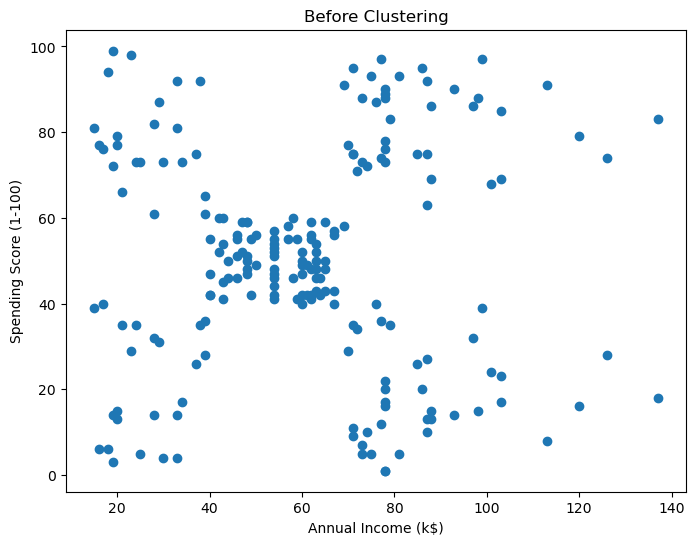

In [4]:
plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'])
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Before Clustering")
plt.show()

## Scale Features

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Elbow Method

The Elbow Method is used to determine the optimal number of clusters (K) in K-Means clustering.

For each value of K, we compute the Within-Cluster Sum of Squares (WCSS):

WCSS = Σᵢ Σₓ∈Cᵢ || x − μᵢ ||²

Where:
- Cᵢ = ith cluster
- μᵢ = centroid of ith cluster
- x = data point in cluster Cᵢ
- || x − μᵢ ||² = squared Euclidean distance

We plot:
K (number of clusters) vs WCSS

The optimal K is chosen at the point where the graph shows a sharp bend (elbow), indicating diminishing returns in reducing WCSS.

C:\Users\KIIT0001\anaconda3\ANACONDA\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\KIIT0001\anaconda3\ANACONDA\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\KIIT0001\anaconda3\ANACONDA\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\KIIT0001\anaconda3\ANACONDA\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning:

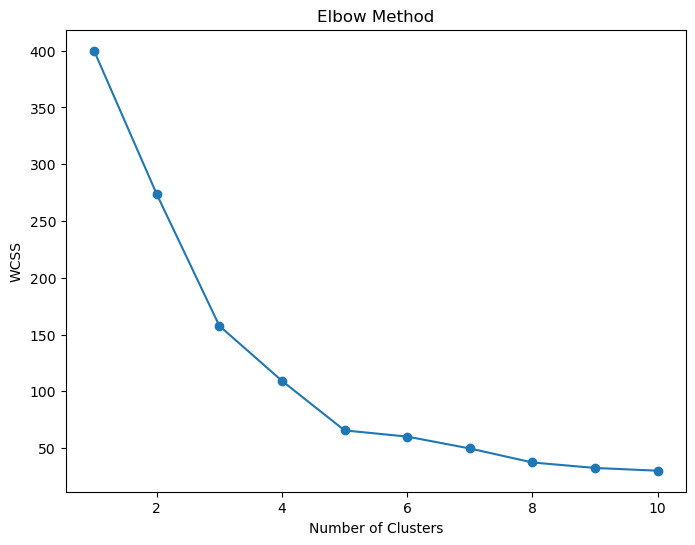

In [6]:
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

## Apply K-Means (K = 5)

In [7]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

C:\Users\KIIT0001\anaconda3\ANACONDA\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


## Visualize Clusters

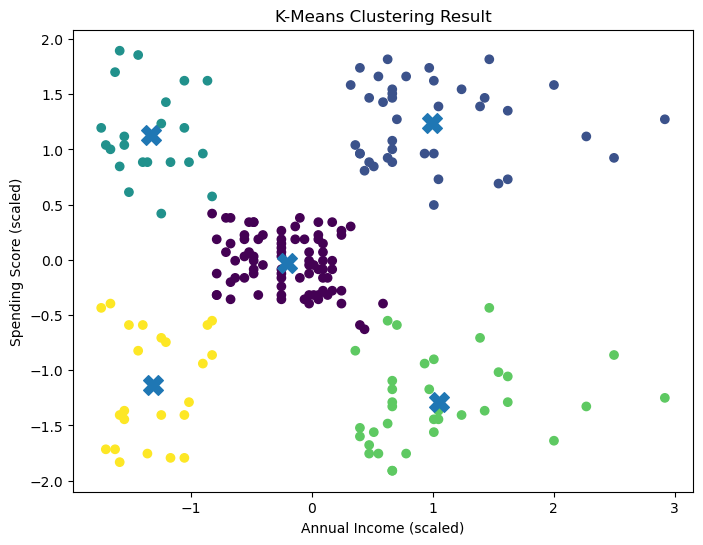

In [8]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters)
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            s=200,
            marker='X')

plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.title("K-Means Clustering Result")
plt.show()